In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import anndata as ad
import scanpy as sc
import squidpy as sq


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/LCL/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  Fil

In [2]:
# ----------------------------
# 0) Paths
# ----------------------------
sim_dir = "./sim_datasets"
out_dir = "./fig/sim"
os.makedirs(out_dir, exist_ok=True)

paths = {
    "easy": os.path.join(sim_dir, "sim_easy.h5ad"),
    "medium": os.path.join(sim_dir, "sim_medium.h5ad"),
    "hard": os.path.join(sim_dir, "sim_hard.h5ad"),
}

# ----------------------------
# 1) Load sims
# ----------------------------
sims = {name: ad.read_h5ad(p) for name, p in paths.items()}

print("Loaded simulation datasets:")
for name, sim in sims.items():
    print(
        f"  {name}: {sim.n_obs} cells × {sim.n_vars} genes | "
        f"patterns={sim.var['pattern_type'].value_counts().to_dict()} | "
        f"theta={sim.uns.get('sim_theta', None)}"
    )

Loaded simulation datasets:
  easy: 9560 cells × 300 genes | patterns={'null': 150, 'gp': 60, 'hotspot': 45, 'stripes': 45} | theta=5.0
  medium: 9560 cells × 300 genes | patterns={'null': 150, 'gp': 60, 'hotspot': 45, 'stripes': 45} | theta=5.0
  hard: 9560 cells × 300 genes | patterns={'null': 150, 'gp': 60, 'hotspot': 45, 'stripes': 45} | theta=5.0


### Run Moran + Geary on a single dataset

In [3]:
from scipy.stats import kendalltau, ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

def run_moran_geary(sim, n_perms=200):
    
    # Run Moran
    sq.gr.spatial_autocorr(sim, mode="moran", n_perms=n_perms)
    moran = sim.uns["moranI"].copy()
    moran["method"] = "moran"
    
    # Run Geary
    sq.gr.spatial_autocorr(sim, mode="geary", n_perms=n_perms)
    geary = sim.uns["gearyC"].copy()
    geary["method"] = "geary"
    
    # Merge with truth
    moran = moran.join(sim.var[["is_spatial", "pattern_type"]])
    geary = geary.join(sim.var[["is_spatial", "pattern_type"]])
    
    return moran, geary

### Evaluation function
Moran: higher I = more spatial
Geary: lower C = more spatial → use score = -C

In [4]:
def evaluate_scores(df, score_col, truth_col="is_spatial"):
    
    score = df[score_col].values
    truth = df[truth_col].values
    
    # Kendall tau
    tau, _ = kendalltau(score, truth)
    
    # AUROC
    auroc = roc_auc_score(truth, score)
    
    # AUPRC
    auprc = average_precision_score(truth, score)
    
    # Find p-value column automatically
    pcol = [c for c in df.columns if "pval" in c][0]
    null_p = df.loc[df["pattern_type"]=="null", pcol].values
    
    ks_stat, _ = ks_2samp(null_p, np.random.uniform(size=len(null_p)))
    
    return tau, auroc, auprc, ks_stat

### Run on all three simulation datasets

In [5]:
results = []

for name, sim in sims.items():
    
    print(f"Running Moran/Geary on {name}...")
    
    moran, geary = run_moran_geary(sim, n_perms=200)
    
    # Moran evaluation
    tau_m, auroc_m, auprc_m, ks_m = evaluate_scores(moran, "I")
    
    # Geary evaluation (use -C)
    geary["negC"] = -geary["C"]
    tau_g, auroc_g, auprc_g, ks_g = evaluate_scores(geary, "negC")
    
    results.append({
        "difficulty": name,
        "method": "Moran",
        "kendall_tau": tau_m,
        "auroc": auroc_m,
        "auprc": auprc_m,
        "ks_null": ks_m
    })
    
    results.append({
        "difficulty": name,
        "method": "Geary",
        "kendall_tau": tau_g,
        "auroc": auroc_g,
        "auprc": auprc_g,
        "ks_null": ks_g
    })

results_df = pd.DataFrame(results)
results_df

Running Moran/Geary on easy...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

Running Moran/Geary on medium...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

Running Moran/Geary on hard...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

,difficulty,method,kendall_tau,auroc,auprc,ks_null
0,easy,Moran,0.708288,1.000000,1.000000,0.860000
1,easy,Geary,0.708288,1.000000,1.000000,0.833333
2,medium,Moran,0.687071,0.985022,0.989172,0.526667
3,medium,Geary,0.683482,0.982489,0.987404,0.573333
4,hard,Moran,0.516326,0.864489,0.898810,0.520000
5,hard,Geary,0.477544,0.837111,0.881363,0.513333


### QQ Plot (All three on one plot)

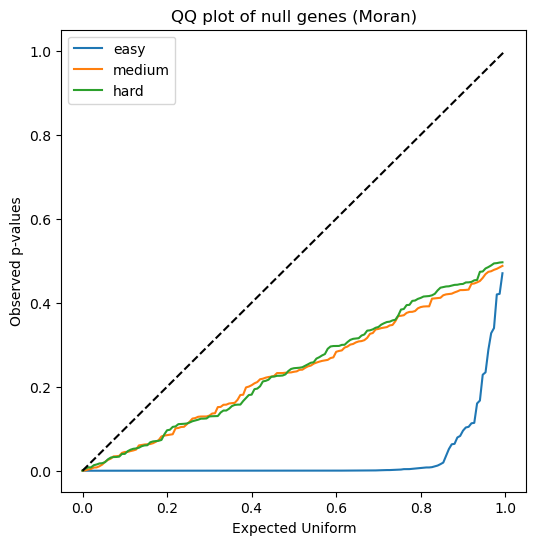

In [6]:
plt.figure(figsize=(6,6))

for name, sim in sims.items():
    moran = sim.uns["moranI"]
    pcol = [c for c in moran.columns if "pval" in c][0]
    
    null_p = moran.loc[sim.var["pattern_type"]=="null", pcol].values
    null_p = np.sort(null_p)
    
    exp = np.linspace(0,1,len(null_p),endpoint=False)
    
    plt.plot(exp, null_p, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot of null genes (Moran)")
plt.legend()
plt.show()

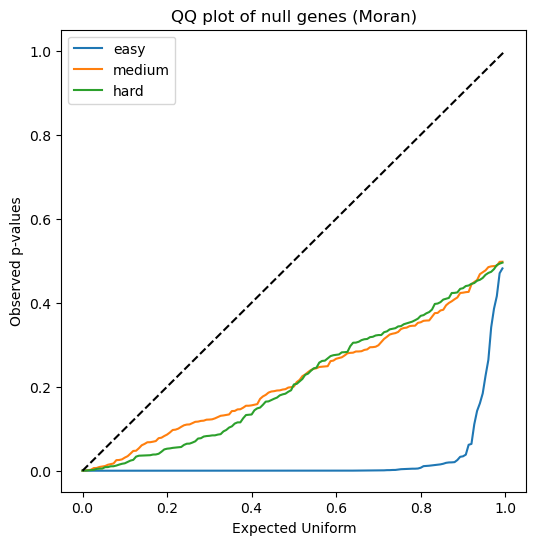

In [8]:
plt.figure(figsize=(6,6))

for name, sim in sims.items():
    moran = sim.uns["gearyC"]
    pcol = [c for c in moran.columns if "pval" in c][0]
    
    null_p = moran.loc[sim.var["pattern_type"]=="null", pcol].values
    null_p = np.sort(null_p)
    
    exp = np.linspace(0,1,len(null_p),endpoint=False)
    
    plt.plot(exp, null_p, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot of null genes (Moran)")
plt.legend()
plt.show()

### save the results

In [11]:
result_dir = "./results/sim/moran_geary"
fig_dir = "./fig/sim/moran_geary"
os.makedirs(result_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

In [10]:
for name, sim in sims.items():
    
    print(f"Running Moran/Geary on {name}...")
    
    moran, geary = run_moran_geary(sim, n_perms=200)

    # Save per-gene results
    moran_out = os.path.join(result_dir, f"{name}_moran_per_gene.csv")
    geary_out = os.path.join(result_dir, f"{name}_geary_per_gene.csv")

    moran.to_csv(moran_out)
    geary.to_csv(geary_out)

    print(f"Saved per-gene results to:")
    print(" ", moran_out)
    print(" ", geary_out)

Running Moran/Geary on easy...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

Saved per-gene results to:
  ./results/moran_geary/easy_moran_per_gene.csv
  ./results/moran_geary/easy_geary_per_gene.csv
Running Moran/Geary on medium...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

Saved per-gene results to:
  ./results/moran_geary/medium_moran_per_gene.csv
  ./results/moran_geary/medium_geary_per_gene.csv
Running Moran/Geary on hard...


  0%|          | 0/200 [00:00<?, ?/s]/opt/anaconda3/envs/LCL/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/LCL/lib/python3.10/threading.py", line 973, in _bootstrap
    self._bootstrap_inner()
  File "/opt/anac

Saved per-gene results to:
  ./results/moran_geary/hard_moran_per_gene.csv
  ./results/moran_geary/hard_geary_per_gene.csv


In [12]:
# Moran QQ
plt.figure(figsize=(6,6))

for name, sim in sims.items():
    moran = sim.uns["moranI"]
    pcol = [c for c in moran.columns if "pval" in c][0]
    
    null_p = moran.loc[sim.var["pattern_type"]=="null", pcol].values
    null_p = np.sort(null_p)
    exp = np.linspace(0,1,len(null_p),endpoint=False)
    
    plt.plot(exp, null_p, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot of null genes (Moran)")
plt.legend()

qq_moran_path = os.path.join(fig_dir, "qq_moran.png")
plt.savefig(qq_moran_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", qq_moran_path)

Saved: ./fig/sim/moran_geary/qq_moran.png


In [13]:
# Geary QQ
plt.figure(figsize=(6,6))

for name, sim in sims.items():
    geary = sim.uns["gearyC"]
    pcol = [c for c in geary.columns if "pval" in c][0]
    
    null_p = geary.loc[sim.var["pattern_type"]=="null", pcol].values
    null_p = np.sort(null_p)
    exp = np.linspace(0,1,len(null_p),endpoint=False)
    
    plt.plot(exp, null_p, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Expected Uniform")
plt.ylabel("Observed p-values")
plt.title("QQ plot of null genes (Geary)")
plt.legend()

qq_geary_path = os.path.join(fig_dir, "qq_geary.png")
plt.savefig(qq_geary_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", qq_geary_path)

Saved: ./fig/sim/moran_geary/qq_geary.png
